### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv('data\\stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

In [7]:
df.info

<bound method DataFrame.info of      gender race_ethnicity parental_level_of_education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test_preparation_course  math_score  reading_score  writing_score  
0                      none    

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [15]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [21]:
df['Total_Marks'] = df['math_score'] + df['writing_score'] + df['reading_score']
df['Average_Marks'] = df['Total_Marks'] / 3

In [22]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,TotalMarks,AverageMarks,Total_Marks,Average_Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333,229,76.333333


In [23]:
df=df.drop(['TotalMarks','AverageMarks'],axis=1)

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Marks,Average_Marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [28]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical Features:", numerical_features)
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
print("Categorical Features:", categorical_features)

Numerical Features: ['math_score', 'reading_score', 'writing_score', 'Total_Marks', 'Average_Marks']
Categorical Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [29]:
df.corr

<bound method DataFrame.corr of      gender race_ethnicity parental_level_of_education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test_preparation_course  math_score  reading_score  writing_score  \
0                      none   

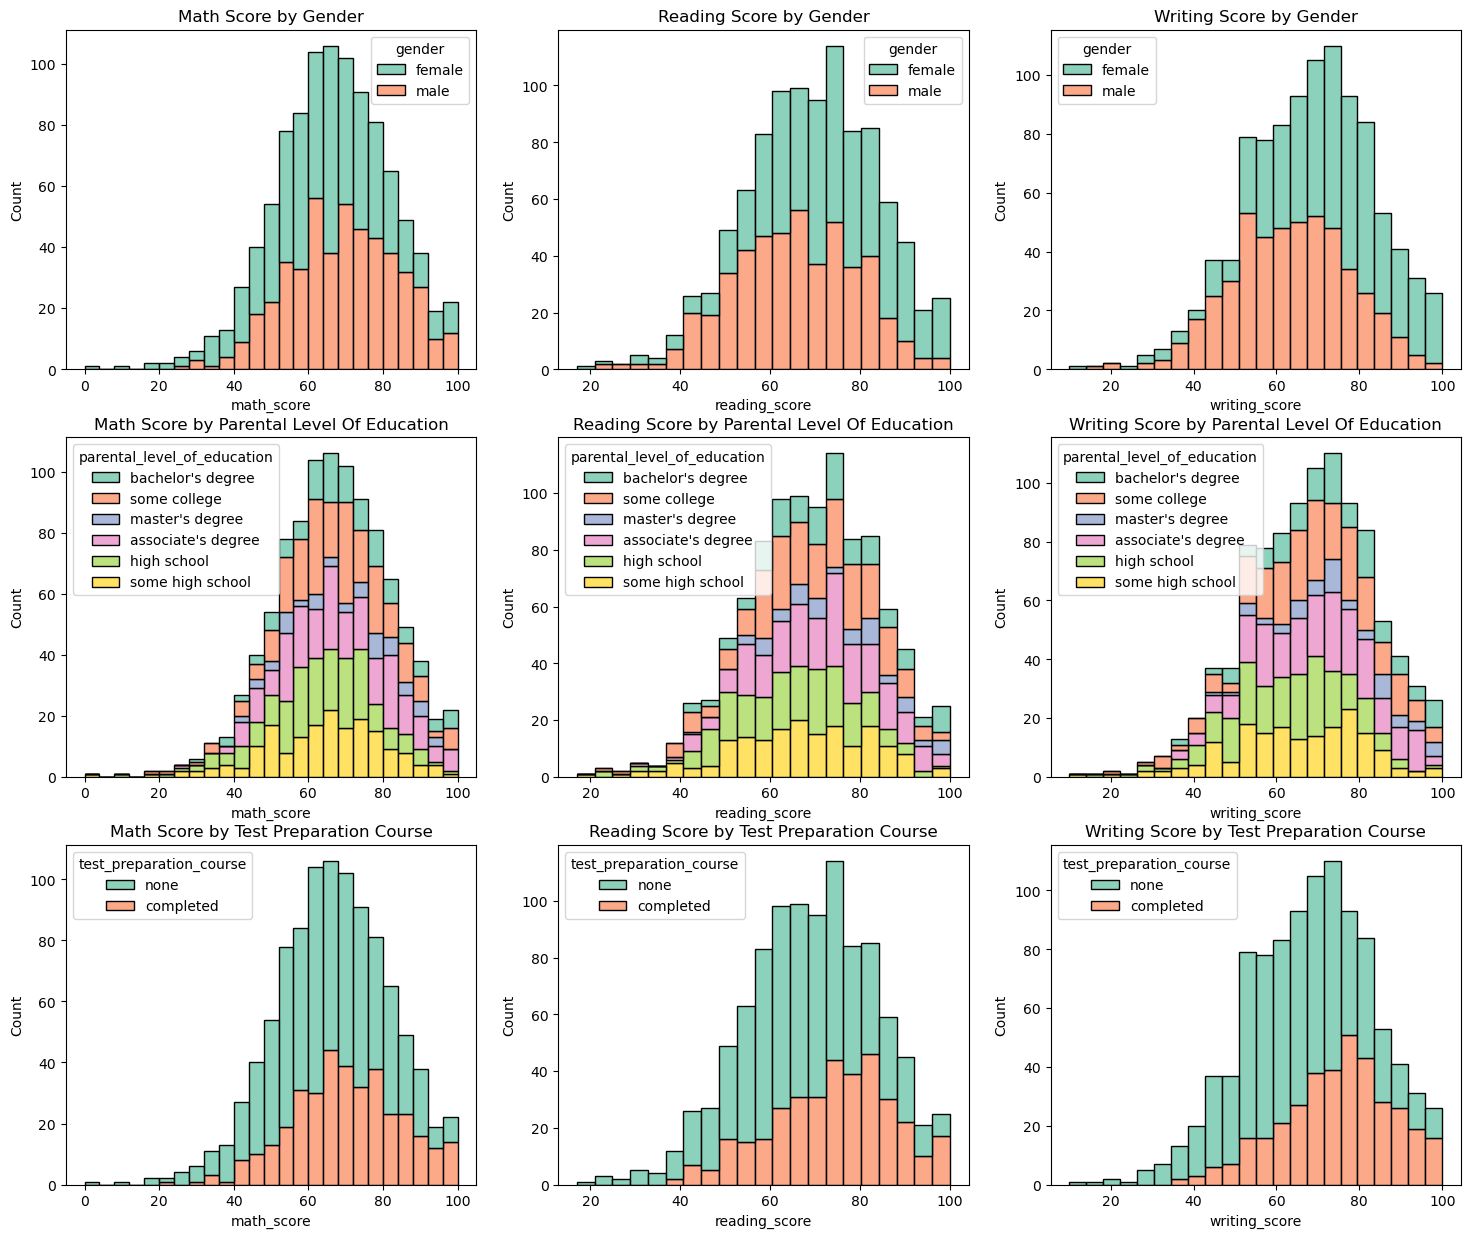

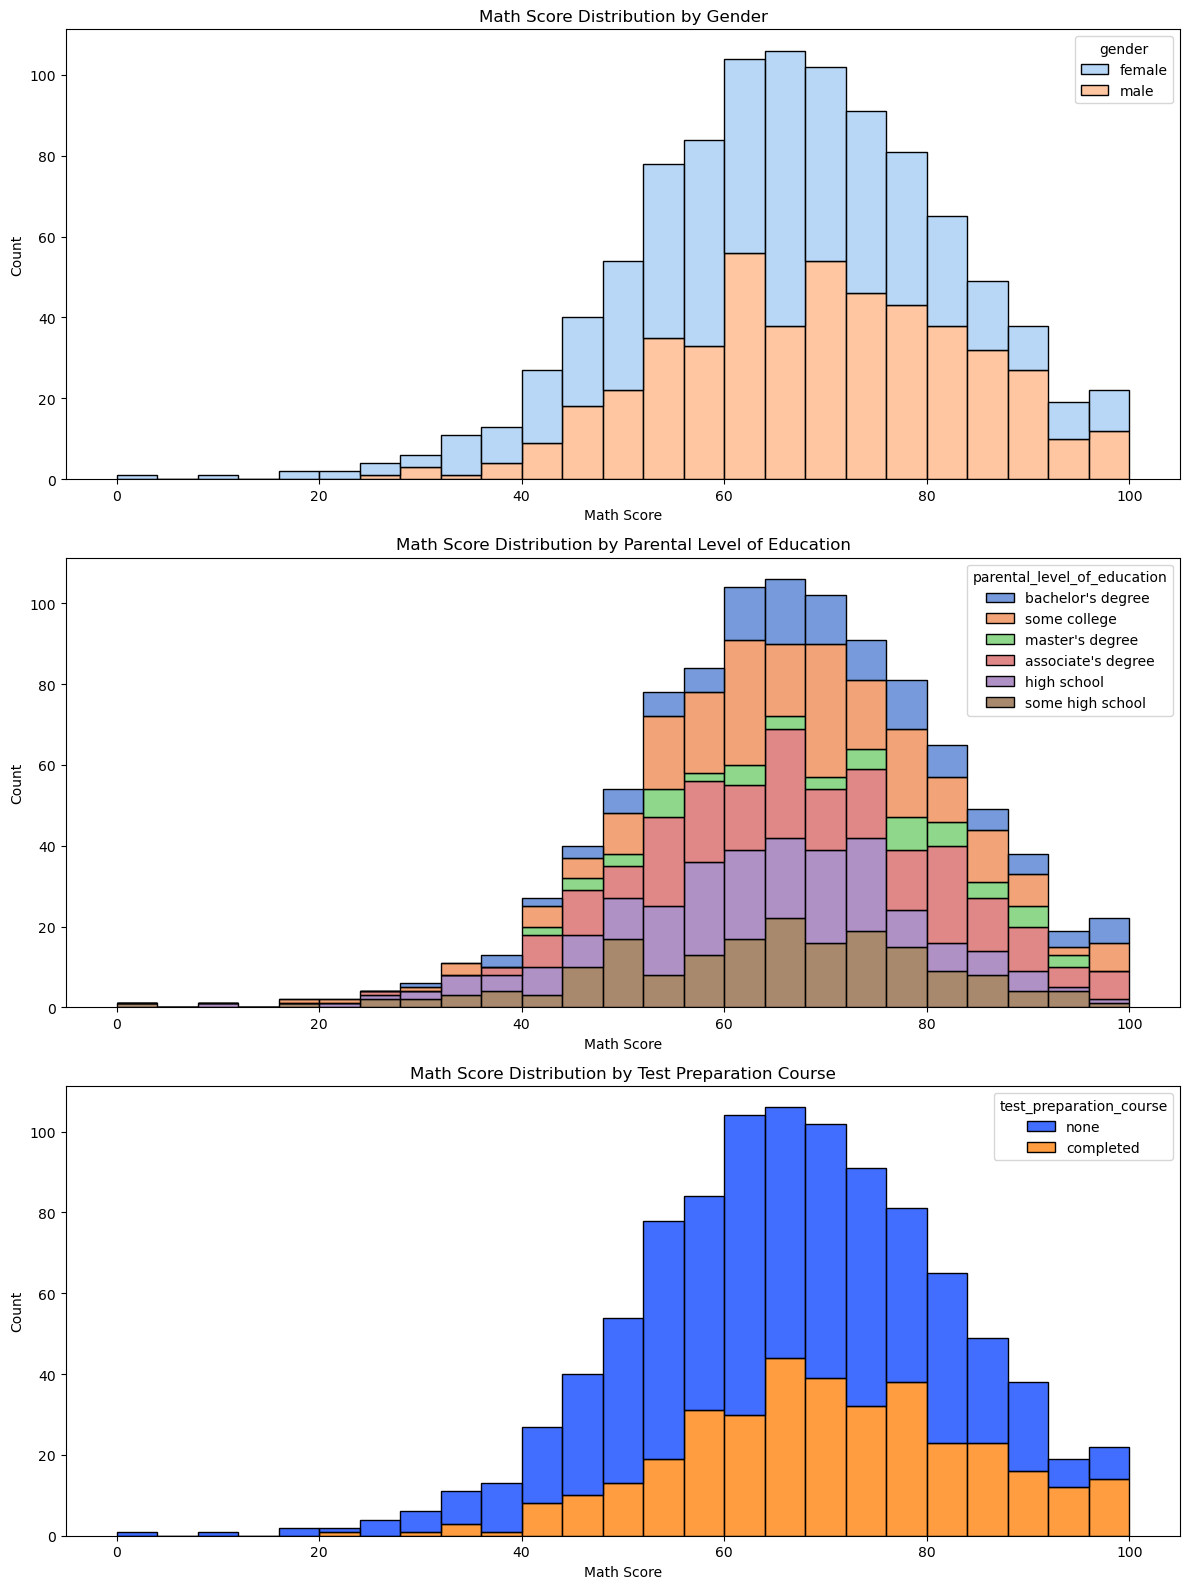

In [31]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

categories = ['gender', 'parental_level_of_education', 'test_preparation_course']
scores = ['math_score', 'reading_score', 'writing_score']

for row, cat in enumerate(categories):
	for col, score in enumerate(scores):
		sns.histplot(
			data=df,
			x=score,
			hue=cat,
			multiple='stack',
			kde=False,
			ax=axes[row, col],
			palette='Set2'
		)
		axes[row, col].set_title(f'{score.replace("_", " ").title()} by {cat.replace("_", " ").title()}')
		
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

sns.histplot(data=df, x='math_score', hue='gender', multiple='stack', palette='pastel', ax=axes[0])
axes[0].set_title('Math Score Distribution by Gender')
axes[0].set_xlabel('Math Score')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='math_score', hue='parental_level_of_education', multiple='stack', palette='muted', ax=axes[1])
axes[1].set_title('Math Score Distribution by Parental Level of Education')
axes[1].set_xlabel('Math Score')
axes[1].set_ylabel('Count')

sns.histplot(data=df, x='math_score', hue='test_preparation_course', multiple='stack', palette='bright', ax=axes[2])
axes[2].set_title('Math Score Distribution by Test Preparation Course')
axes[2].set_xlabel('Math Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()